In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ALLFLOWMETER_HIKARI2021.csv')

In [ ]:
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis = 1, inplace=True)

In [ ]:
df.shape

(555278, 86)

In [ ]:
df_exclude_object = df.select_dtypes(exclude=['object'])

In [ ]:
df_exclude_object['Label'].value_counts()

0    517582
1     37696
Name: Label, dtype: int64

In [ ]:
df_exclude_object.shape

(555278, 82)

In [ ]:
df_exclude_object.head(5)

,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Label
0,13316,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,1
1,13318,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,...,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,1
2,13320,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,...,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,1
3,13322,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,...,123182.931318,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0,1
4,13324,443,7.780611,14,14,6,5,1.799345,1.799345,3.598689,...,126016.885411,7.545305e+06,7.545305e+06,7.545305e+06,7.545305e+06,0.0,29200,65160,0,1


In [ ]:
from sklearn.model_selection import train_test_split
X = df_exclude_object.iloc[:,:-1]
y = df['Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

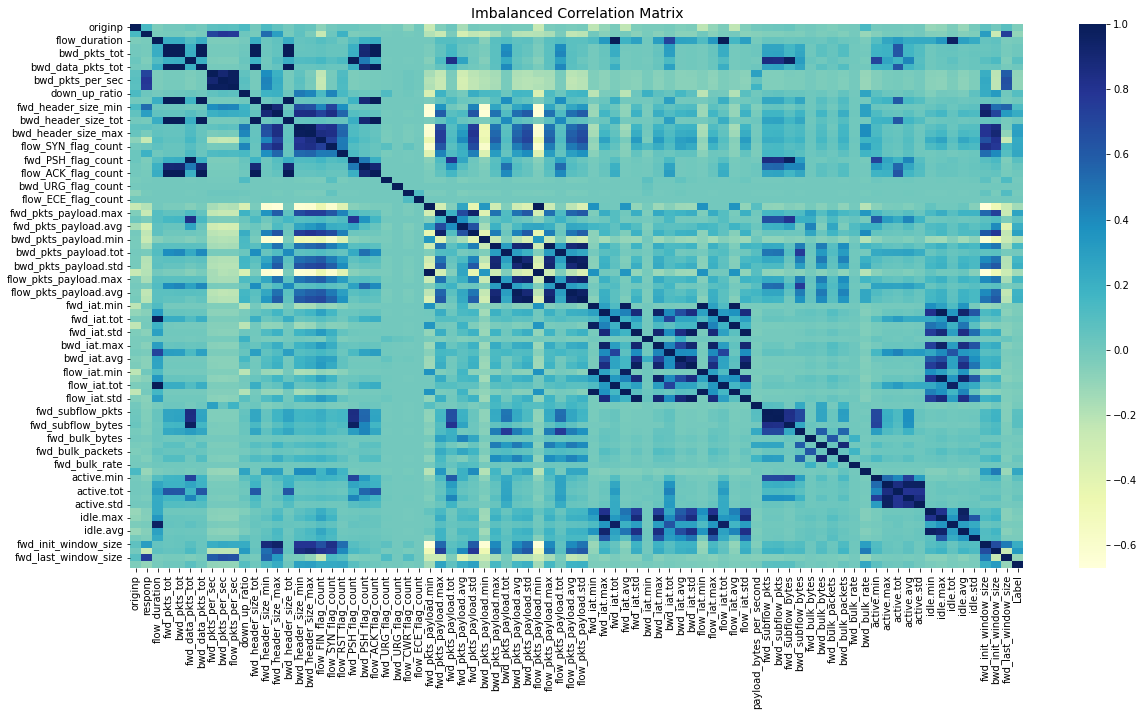

In [ ]:
# Sample figsize in inches
fig, ax = plt.subplots(figsize=(20,10))
# Imbalanced DataFrame Correlation
corr = df_exclude_object.corr()
sns.heatmap(corr, cmap='YlGnBu', annot_kws={'size':30}, ax=ax)
ax.set_title("Imbalanced Correlation Matrix", fontsize=14)
plt.show()

#Undersampling
menggunakan nearmiss

https://medium.com/grabngoinfo/four-oversampling-and-under-sampling-methods-for-imbalanced-classification-using-python-7304aedf9037

In [ ]:
from imblearn.under_sampling import NearMiss

In [ ]:
# Under sample the majority class
nearmiss = NearMiss(version=3)
X_train_nearmiss, y_train_nearmiss= nearmiss.fit_resample(X_train, y_train)


In [ ]:

from collections import Counter
#sebelum undersampling
print("Sebelum undersampling:")
print(f"Training target statistics: {Counter(y_train)}")
print(f"Testing target statistics: {Counter(y_test)}")
#setelah undersampling
print("\nSetelah undersampling:")
print(f"Training target statistics: {Counter(y_train_nearmiss)}")
print(f"Testing target statistics: {Counter(y_test)}")

Sebelum undersampling:
Training target statistics: Counter({0: 362125, 1: 26569})
Testing target statistics: Counter({0: 155457, 1: 11127})

Setelah undersampling:
Training target statistics: Counter({0: 26569, 1: 26569})
Testing target statistics: Counter({0: 155457, 1: 11127})


##Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=3000)

In [ ]:
logmodel.fit(X_train_nearmiss, y_train_nearmiss)

LogisticRegression(max_iter=3000)

In [ ]:
predLR = logmodel.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, predLR))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89    155457
           1       0.16      0.45      0.24     11127

    accuracy                           0.80    166584
   macro avg       0.56      0.64      0.56    166584
weighted avg       0.90      0.80      0.84    166584



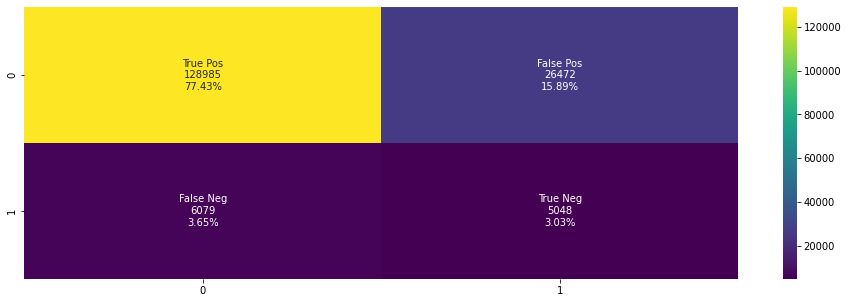

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predLR)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##KNN Classifier
menggunakan n_neighbors default

In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train_nearmiss, y_train_nearmiss)

KNeighborsClassifier()

In [ ]:
predKNN = knn.predict(X_test)

In [ ]:
print(classification_report(y_test, predKNN))

              precision    recall  f1-score   support

           0       0.95      0.76      0.84    155457
           1       0.11      0.41      0.17     11127

    accuracy                           0.74    166584
   macro avg       0.53      0.59      0.51    166584
weighted avg       0.89      0.74      0.80    166584



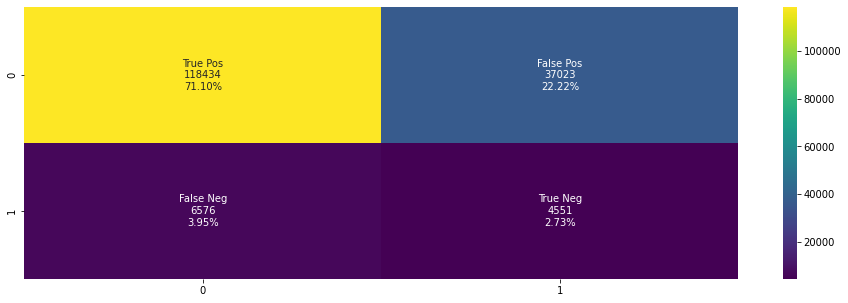

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predKNN)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

## Decision Tree dan Random Forest
max_depth default, n_estimators default

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dtree = DecisionTreeClassifier()

In [ ]:
dtree.fit(X_train_nearmiss, y_train_nearmiss)

DecisionTreeClassifier()

In [ ]:
predDtree = dtree.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(classification_report(y_test, predDtree))

              precision    recall  f1-score   support

           0       0.92      0.52      0.66    155457
           1       0.05      0.33      0.08     11127

    accuracy                           0.51    166584
   macro avg       0.48      0.42      0.37    166584
weighted avg       0.86      0.51      0.62    166584



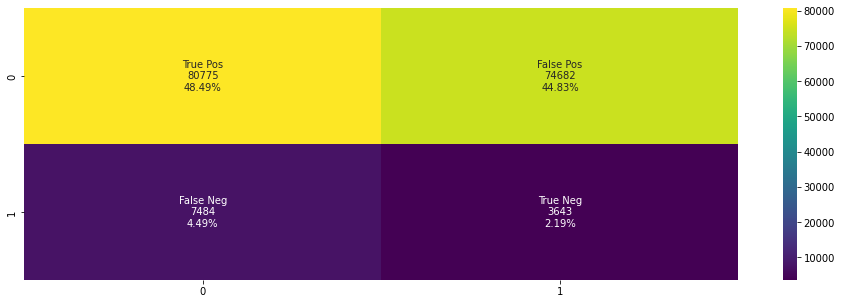

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predDtree)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier()

In [ ]:
rfc.fit(X_train_nearmiss, y_train_nearmiss)

RandomForestClassifier()

In [ ]:
predRFC = rfc.predict(X_test)

In [ ]:
print(classification_report(y_test, predRFC))

              precision    recall  f1-score   support

           0       0.90      0.40      0.56    155457
           1       0.04      0.36      0.07     11127

    accuracy                           0.40    166584
   macro avg       0.47      0.38      0.32    166584
weighted avg       0.84      0.40      0.52    166584



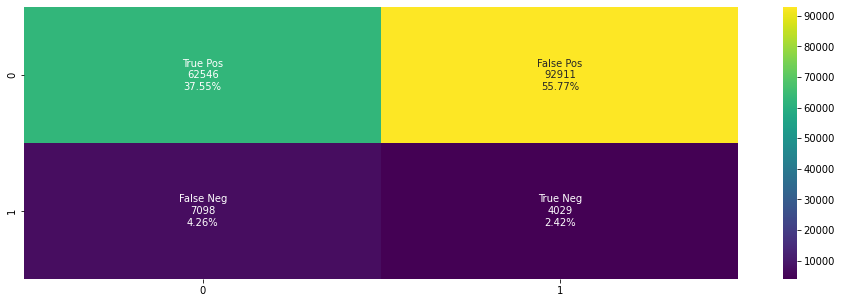

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predRFC)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##Naive Bayes: Gaussian Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Build a Gaussian Classifier
nbgc = GaussianNB()

In [ ]:
# Model training
nbgc.fit(X_train_nearmiss, y_train_nearmiss)

# Predict Output
predNBGC = nbgc.predict(X_test)

In [ ]:
print(classification_report(y_test, predNBGC))

              precision    recall  f1-score   support

           0       0.87      0.40      0.55    155457
           1       0.02      0.18      0.04     11127

    accuracy                           0.38    166584
   macro avg       0.45      0.29      0.29    166584
weighted avg       0.81      0.38      0.51    166584



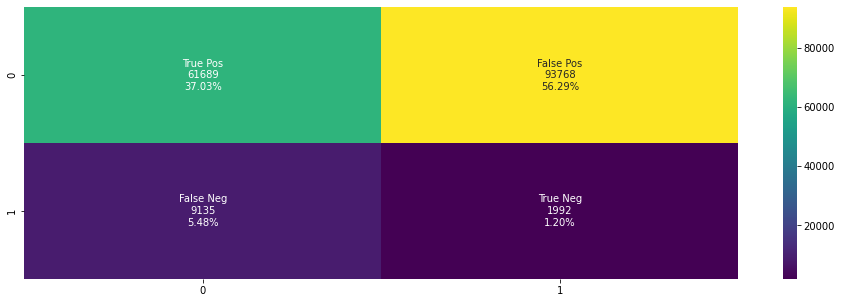

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predNBGC)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##SVC

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc = SVC()
'''
generalization:
low C = high bias, low variance
high C = low bias, low variance

low gamma = high variance
high gamma = low variance

gamma ada tergantung rbf
'''

'\ngeneralization:\nlow C = high bias, low variance\nhigh C = low bias, low variance\n\nlow gamma = high variance\nhigh gamma = low variance\n\ngamma ada tergantung rbf\n'

In [ ]:
svc.fit(X_train_nearmiss, y_train_nearmiss)

SVC()

In [ ]:
pred_svc = svc.predict(X_test)

In [ ]:
print(classification_report(y_test, pred_svc))

              precision    recall  f1-score   support

           0       0.79      0.13      0.22    155457
           1       0.04      0.53      0.08     11127

    accuracy                           0.16    166584
   macro avg       0.42      0.33      0.15    166584
weighted avg       0.74      0.16      0.21    166584



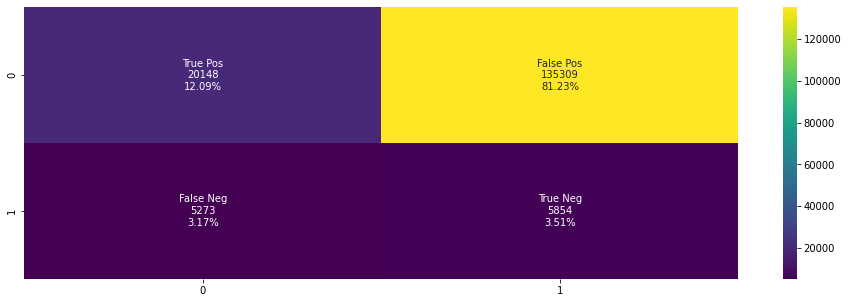

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, pred_svc)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');